# CP2 — Эксперименты и моделирование

**Задача:** Регрессия — предсказание PM2.5 (мкг/м³) в атмосфере Пекина.

**Что делаем в CP2:**
1. Дополнительный feature engineering (новые признаки-взаимодействия).
2. Эксперименты с 5 моделями: Ridge, HistGBM, RandomForest, XGBoost, LightGBM.
3. Подбор гиперпараметров через Optuna (байесовская оптимизация).
4. Эксперимент с уменьшением размерности (PCA + LightGBM).
5. Ансамблирование (усреднение предсказаний лучших моделей).
6. Таблица экспериментов и обоснование финальной модели.

**Основная метрика:** RMSE на val-выборке.

In [1]:
import sys
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna
import lightgbm as lgb

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.preprocessing import add_interaction_features, build_feature_matrix

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
MODELS_DIR    = os.path.join(PROJECT_ROOT, "models")
IMAGES_DIR    = os.path.join(PROJECT_ROOT, "report", "images")

os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_theme(style="whitegrid")
%matplotlib inline

/Users/sneguradik/Projects/hseml-group-project-v-ivanov/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Загрузка данных и новые фичи (CP2)

Загружаем обработанные сплиты из CP1 и добавляем взаимодействия из CP2:

| Новый признак | Смысл |
|---|---|
| `O3_to_NO2` | Соотношение озона к NO2 — индикатор фотохимических реакций |
| `wind_u`, `wind_v` | Скорость ветра × sin/cos направления — вектор переноса частиц |
| `pm10_pm25_ratio` | Доля крупных частиц — косвенный признак источника загрязнения |
| `temp_dewp_diff` | Разность температуры и точки росы — «сухость» воздуха |
| `season` | Сезон (0=зима, 1=весна, 2=лето, 3=осень) |

In [2]:
train = pd.read_parquet(os.path.join(PROCESSED_DIR, "train.parquet"))
val   = pd.read_parquet(os.path.join(PROCESSED_DIR, "val.parquet"))
test  = pd.read_parquet(os.path.join(PROCESSED_DIR, "test.parquet"))

train = add_interaction_features(train)
val   = add_interaction_features(val)
test  = add_interaction_features(test)

print(f"Train: {len(train):,}  |  Val: {len(val):,}  |  Test: {len(test):,}")
print(f"Столбцов после CP2 feature engineering: {train.shape[1]}")

Train: 295,871  |  Val: 104,617  |  Test: 16,504
Столбцов после CP2 feature engineering: 39


## 2. Матрица признаков

In [3]:
TARGET    = "PM2.5"
DROP_COLS = ["datetime", "station", "year", "month", "day", "hour", "No", TARGET]

X_train, y_train = build_feature_matrix(train, target_col=TARGET, drop_cols=DROP_COLS)
X_val,   y_val   = build_feature_matrix(val,   target_col=TARGET, drop_cols=DROP_COLS)
X_test,  y_test  = build_feature_matrix(test,  target_col=TARGET, drop_cols=DROP_COLS)

# wd_sin/wd_cos are NaN for "cv" (calm) wind direction — fill with 0 (no directional transport)
for df_X in [X_train, X_val, X_test]:
    nan_cols = df_X.columns[df_X.isnull().any()].tolist()
    if nan_cols:
        print(f"Filling NaN in: {nan_cols}")
        df_X.fillna(0, inplace=True)

FEATURE_NAMES = list(X_train.columns)
print(f"Всего признаков: {len(FEATURE_NAMES)}")
print(FEATURE_NAMES)

Filling NaN in: ['PM2.5_roll3', 'PM2.5_roll24']
Всего признаков: 31
['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'wd_sin', 'wd_cos', 'station_enc', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day_of_week', 'is_weekend', 'PM2.5_lag1', 'PM2.5_lag2', 'PM2.5_lag3', 'PM2.5_lag24', 'PM2.5_roll3', 'PM2.5_roll24', 'O3_to_NO2', 'wind_u', 'wind_v', 'pm10_pm25_ratio', 'temp_dewp_diff', 'season']


## 3. Вспомогательные функции

In [4]:
experiment_log = []

def log_experiment(name, model, X_tr, y_tr, X_v, y_v, notes=""):
    """Fit model, compute metrics, store result."""
    model.fit(X_tr, y_tr)
    y_pred_tr = np.clip(model.predict(X_tr), 0, None)
    y_pred_v  = np.clip(model.predict(X_v),  0, None)

    rmse_tr = np.sqrt(mean_squared_error(y_tr, y_pred_tr))
    rmse_v  = np.sqrt(mean_squared_error(y_v,  y_pred_v))
    mae_v   = mean_absolute_error(y_v, y_pred_v)
    r2_v    = r2_score(y_v, y_pred_v)

    row = {
        "Модель":      name,
        "RMSE Train":  round(rmse_tr, 3),
        "RMSE Val":    round(rmse_v,  3),
        "MAE Val":     round(mae_v,   3),
        "R² Val":      round(r2_v,    4),
        "Примечание":  notes,
    }
    experiment_log.append(row)
    print(f"{name:42s}  RMSE={rmse_v:.3f}  MAE={mae_v:.3f}  R²={r2_v:.4f}")
    return model, y_pred_v


# Scaled versions for linear models
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_v_sc  = scaler.transform(X_val)
X_te_sc = scaler.transform(X_test)

## 4. Эксперименты

### 4.1 Отправная точка: Linear Regression (все фичи включая лаги)

**Гипотеза:** добавление лаговых и скользящих фич улучшит линейную модель относительно CP1-baseline (RMSE=26.21, только сырые фичи).  
**Проверка:** обучаем LR на полном наборе признаков.  
**Ожидание:** RMSE ниже 26.21 за счёт авторегрессионных признаков.

In [5]:
lr = LinearRegression()
lr, _ = log_experiment(
    "LinearRegression (все фичи + лаги)",
    lr, X_tr_sc, y_train, X_v_sc, y_val,
    notes="CP1 baseline + лаги 1/2/3/24, rolling 3/24",
)

LinearRegression (все фичи + лаги)          RMSE=13.394  MAE=8.063  R²=0.9616


### 4.2 Ridge Regression с подбором гиперпараметров (Optuna)

**Гипотеза:** L2-регуляризация снизит переобучение линейной модели.
**Проверка:** подбираем `alpha` через Optuna (TPE-семплер, 30 попыток).
**Ожидание:** небольшое улучшение RMSE по сравнению с LR.

In [6]:
def _ridge_objective(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 1e3, log=True)
    m = Ridge(alpha=alpha, random_state=RANDOM_SEED)
    m.fit(X_tr_sc, y_train)
    pred = np.clip(m.predict(X_v_sc), 0, None)
    return np.sqrt(mean_squared_error(y_val, pred))

study_ridge = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
)
study_ridge.optimize(_ridge_objective, n_trials=30)

best_alpha = study_ridge.best_params["alpha"]
print(f"Лучший alpha: {best_alpha:.4f}")

ridge_best = Ridge(alpha=best_alpha, random_state=RANDOM_SEED)
ridge_best, _ = log_experiment(
    "Ridge (Optuna, 30 trials)",
    ridge_best, X_tr_sc, y_train, X_v_sc, y_val,
    notes=f"alpha={best_alpha:.4f}",
)

Лучший alpha: 0.2780
Ridge (Optuna, 30 trials)                   RMSE=13.394  MAE=8.063  R²=0.9616


### 4.3 HistGradientBoostingRegressor (sklearn)

**Гипотеза:** нелинейная модель на основе градиентного бустинга значительно улучшит RMSE по сравнению с линейными моделями.  
**Проверка:** дефолтные параметры HistGBM (быстрый аналог LightGBM в sklearn).  
**Ожидание:** RMSE ниже линейных моделей.

In [7]:
hgbm = HistGradientBoostingRegressor(
    max_iter=300,
    max_depth=8,
    learning_rate=0.05,
    min_samples_leaf=20,
    random_state=RANDOM_SEED,
)
hgbm, _ = log_experiment(
    "HistGradientBoosting (sklearn)",
    hgbm, X_train, y_train, X_val, y_val,
    notes="max_iter=300, depth=8, lr=0.05",
)

HistGradientBoosting (sklearn)              RMSE=3.233  MAE=1.346  R²=0.9978


### 4.4 Random Forest с подбором гиперпараметров (Optuna)

**Гипотеза:** ансамбль решающих деревьев устойчивее к выбросам и нелинейным зависимостям.  
**Проверка:** Optuna подбирает `max_depth`, `min_samples_leaf`, `max_features` (20 попыток, subsample 50k для скорости).  
**Ожидание:** сопоставимо с бустингом, но, как правило, чуть хуже.

In [8]:
# Subsample for fast optuna search
rng = np.random.default_rng(RANDOM_SEED)
idx = rng.choice(len(X_train), size=50_000, replace=False)
X_tr_sub = X_train.iloc[idx]
y_tr_sub = y_train.iloc[idx]

def _rf_objective(trial):
    params = {
        "max_depth":        trial.suggest_int("max_depth", 8, 25),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features":     trial.suggest_float("max_features", 0.3, 1.0),
        "n_estimators":     100,
    }
    m = RandomForestRegressor(**params, random_state=RANDOM_SEED, n_jobs=-1)
    m.fit(X_tr_sub, y_tr_sub)
    pred = np.clip(m.predict(X_val), 0, None)
    return np.sqrt(mean_squared_error(y_val, pred))

study_rf = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
)
study_rf.optimize(_rf_objective, n_trials=20)

rf_params = study_rf.best_params
rf_params["n_estimators"] = 200
print(f"Лучшие параметры RF: {rf_params}")

rf_best = RandomForestRegressor(**rf_params, random_state=RANDOM_SEED, n_jobs=-1)
rf_best, _ = log_experiment(
    "RandomForest (Optuna, 20 trials)",
    rf_best, X_train, y_train, X_val, y_val,
    notes=str(rf_params),
)

Лучшие параметры RF: {'max_depth': 25, 'min_samples_leaf': 1, 'max_features': 0.978675977551506, 'n_estimators': 200}


RandomForest (Optuna, 20 trials)            RMSE=3.192  MAE=0.324  R²=0.9978


### 4.5 XGBoost с подбором гиперпараметров (Optuna + early stopping)

**Гипотеза:** XGBoost с тюнингом превзойдёт RandomForest и sklearn GBM на этой задаче.  
**Проверка:** Optuna подбирает `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight` (30 попыток, early stopping на val).  
**Ожидание:** RMSE < 10.

In [9]:
def _xgb_objective(trial):
    params = {
        "n_estimators":      1000,
        "max_depth":         trial.suggest_int("max_depth", 4, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
    }
    m = XGBRegressor(
        **params,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        early_stopping_rounds=30,
        eval_metric="rmse",
    )
    m.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    pred = np.clip(m.predict(X_val), 0, None)
    return np.sqrt(mean_squared_error(y_val, pred))

study_xgb = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
)
study_xgb.optimize(_xgb_objective, n_trials=30)

xgb_params = study_xgb.best_params
xgb_params["n_estimators"] = 1000
print(f"Лучшие параметры XGB: {xgb_params}")

xgb_best = XGBRegressor(
    **xgb_params,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    early_stopping_rounds=30,
    eval_metric="rmse",
)
xgb_best.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_pred_xgb_v = np.clip(xgb_best.predict(X_val), 0, None)
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb_v))
mae_xgb  = mean_absolute_error(y_val, y_pred_xgb_v)
r2_xgb   = r2_score(y_val, y_pred_xgb_v)

y_pred_xgb_tr = np.clip(xgb_best.predict(X_train), 0, None)
rmse_xgb_tr = np.sqrt(mean_squared_error(y_train, y_pred_xgb_tr))

experiment_log.append({
    "Модель":     "XGBoost (Optuna, 30 trials)",
    "RMSE Train": round(rmse_xgb_tr, 3),
    "RMSE Val":   round(rmse_xgb,    3),
    "MAE Val":    round(mae_xgb,     3),
    "R² Val":     round(r2_xgb,      4),
    "Примечание": str(xgb_params),
})
print(f"XGBoost (Optuna)  RMSE={rmse_xgb:.3f}  MAE={mae_xgb:.3f}  R²={r2_xgb:.4f}")

Лучшие параметры XGB: {'max_depth': 5, 'learning_rate': 0.04585880854088275, 'subsample': 0.774439933428912, 'colsample_bytree': 0.9382777773056039, 'min_child_weight': 7, 'reg_lambda': 1.2209295074681008, 'n_estimators': 1000}


XGBoost (Optuna)  RMSE=3.024  MAE=0.968  R²=0.9980
Лучшие параметры XGB: {'max_depth': 5, 'learning_rate': 0.04585880854088275, 'subsample': 0.774439933428912, 'colsample_bytree': 0.9382777773056039, 'min_child_weight': 7, 'reg_lambda': 1.2209295074681008, 'n_estimators': 1000}
XGBoost (Optuna)  RMSE=3.024  MAE=0.968  R²=0.9980


### 4.6 LightGBM с подбором гиперпараметров (Optuna + early stopping)

**Гипотеза:** LightGBM обычно быстрее XGBoost и показывает сравнимое или лучшее качество за счёт leaf-wise роста деревьев.  
**Проверка:** Optuna подбирает `num_leaves`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_samples` (30 попыток, early stopping).  
**Ожидание:** лучший результат среди одиночных моделей.

In [10]:
def _lgbm_objective(trial):
    params = {
        "n_estimators":       1000,
        "num_leaves":         trial.suggest_int("num_leaves", 20, 150),
        "max_depth":          trial.suggest_int("max_depth", 4, 12),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":          trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_samples":  trial.suggest_int("min_child_samples", 5, 50),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
    }
    m = LGBMRegressor(
        **params,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    m.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=30, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )
    pred = np.clip(m.predict(X_val), 0, None)
    return np.sqrt(mean_squared_error(y_val, pred))

study_lgbm = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
)
study_lgbm.optimize(_lgbm_objective, n_trials=30)

lgbm_params = study_lgbm.best_params
lgbm_params["n_estimators"] = 1000
print(f"Лучшие параметры LGBM: {lgbm_params}")

lgbm_best = LGBMRegressor(
    **lgbm_params,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
lgbm_best.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(-1),
    ],
)

y_pred_lgbm_v = np.clip(lgbm_best.predict(X_val), 0, None)
rmse_lgbm  = np.sqrt(mean_squared_error(y_val, y_pred_lgbm_v))
mae_lgbm   = mean_absolute_error(y_val, y_pred_lgbm_v)
r2_lgbm    = r2_score(y_val, y_pred_lgbm_v)

y_pred_lgbm_tr = np.clip(lgbm_best.predict(X_train), 0, None)
rmse_lgbm_tr = np.sqrt(mean_squared_error(y_train, y_pred_lgbm_tr))

experiment_log.append({
    "Модель":     "LightGBM (Optuna, 30 trials)",
    "RMSE Train": round(rmse_lgbm_tr, 3),
    "RMSE Val":   round(rmse_lgbm,    3),
    "MAE Val":    round(mae_lgbm,     3),
    "R² Val":     round(r2_lgbm,      4),
    "Примечание": str(lgbm_params),
})
print(f"LightGBM (Optuna)  RMSE={rmse_lgbm:.3f}  MAE={mae_lgbm:.3f}  R²={r2_lgbm:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002380 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5052
[LightGBM] [Info] Number of data points in the train set: 295871, number of used features: 31
[LightGBM] [Info] Start training from score 79.356743


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002730 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5052
[LightGBM] [Info] Number of data points in the train set: 295871, number of used features: 31
[LightGBM] [Info] Start training from score 79.356743


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LightGBM (Optuna)  RMSE=2.300  MAE=0.633  R²=0.9989
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002435 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5052
[LightGBM] [Info] Number of data points in the train set: 295871, number of used features: 31
[LightGBM] [Info] Start training from score 79.356743
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002604 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5052
[LightGBM] [Info] Number of data points in the train set: 295871, number of used features: 31
[LightGBM] [Info] Start training from score 79.356743
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

## 5. Уменьшение размерности (PCA)

**Гипотеза:** у нас ~38 признаков — часть из них коррелирует между собой. PCA позволит сжать пространство признаков без потери информации.  
**Проверка:**
1. Смотрим, сколько компонент объясняют 95% дисперсии.
2. Визуализируем первые 2 компоненты.
3. Обучаем LightGBM на PCA-признаках и сравниваем с исходными.

Компонент для 95% дисперсии: 19  |  для 99%: 25  |  всего: 31


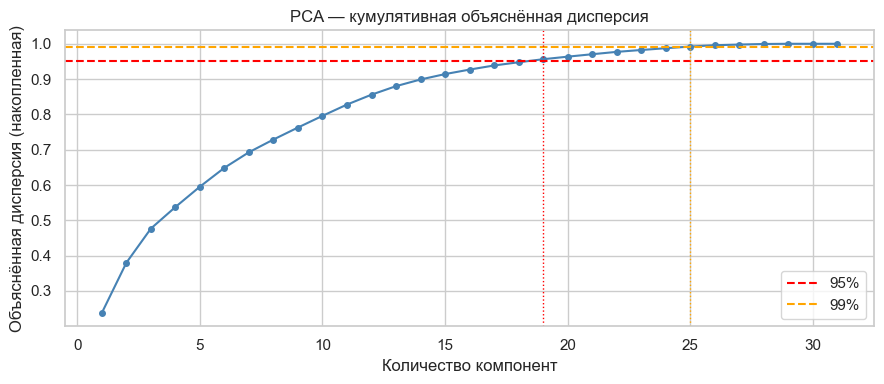

Компонент для 95% дисперсии: 19  |  для 99%: 25  |  всего: 31


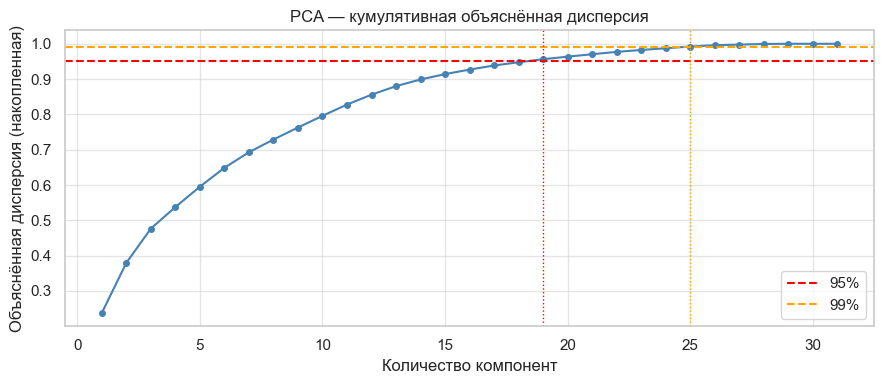

In [11]:
pca_full = PCA(random_state=RANDOM_SEED)
pca_full.fit(X_tr_sc)

explained = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.searchsorted(explained, 0.95) + 1
n_99 = np.searchsorted(explained, 0.99) + 1
print(f"Компонент для 95% дисперсии: {n_95}  |  для 99%: {n_99}  |  всего: {len(explained)}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(explained) + 1), explained, marker="o", markersize=4, color="steelblue")
ax.axhline(0.95, ls="--", color="red", lw=1.5, label="95%")
ax.axhline(0.99, ls="--", color="orange", lw=1.5, label="99%")
ax.axvline(n_95, ls=":", color="red", lw=1)
ax.axvline(n_99, ls=":", color="orange", lw=1)
ax.set_xlabel("Количество компонент")
ax.set_ylabel("Объяснённая дисперсия (накопленная)")
ax.set_title("PCA — кумулятивная объяснённая дисперсия")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "pca_variance.png"), dpi=100)
plt.show()

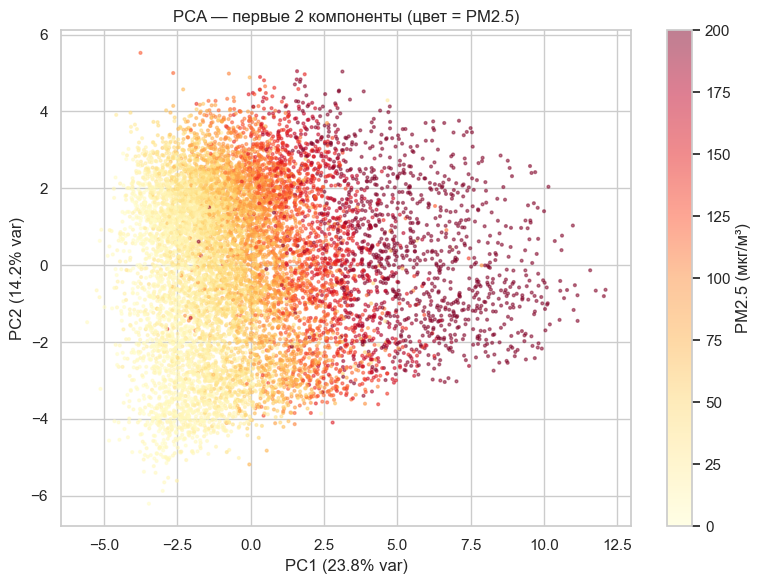

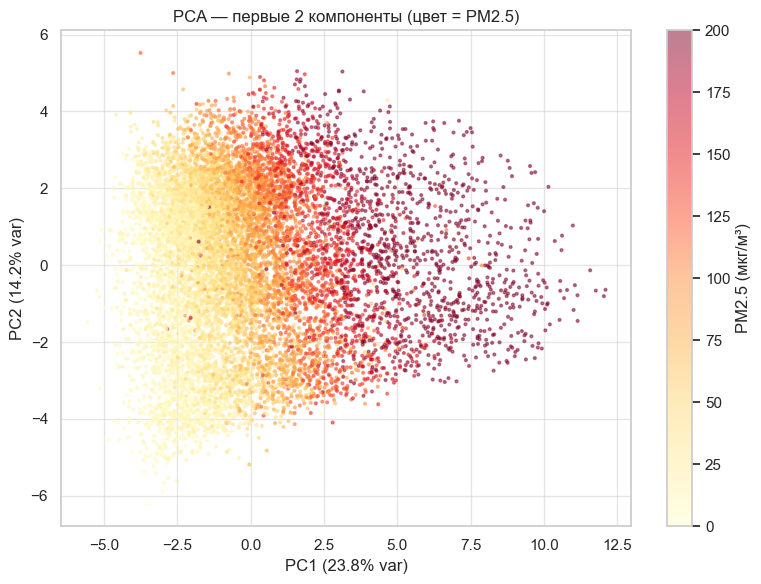

In [12]:
# Visualize first 2 PCs coloured by PM2.5
pca_2d = PCA(n_components=2, random_state=RANDOM_SEED)
Z_train_2d = pca_2d.fit_transform(X_tr_sc)

sample_idx = np.random.choice(len(Z_train_2d), size=10_000, replace=False)
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    Z_train_2d[sample_idx, 0],
    Z_train_2d[sample_idx, 1],
    c=y_train.values[sample_idx],
    cmap="YlOrRd", s=4, alpha=0.5,
    vmin=0, vmax=200,
)
plt.colorbar(sc, ax=ax, label="PM2.5 (мкг/м³)")
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("PCA — первые 2 компоненты (цвет = PM2.5)")
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "pca_2d.png"), dpi=100)
plt.show()

In [13]:
# LightGBM on PCA-reduced features (95% variance)
pca_95 = PCA(n_components=n_95, random_state=RANDOM_SEED)
X_tr_pca = pca_95.fit_transform(X_tr_sc)
X_v_pca  = pca_95.transform(X_v_sc)

lgbm_pca = LGBMRegressor(
    **lgbm_params,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
lgbm_pca.fit(
    X_tr_pca, y_train,
    eval_set=[(X_v_pca, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(-1),
    ],
)
y_pred_pca = np.clip(lgbm_pca.predict(X_v_pca), 0, None)
rmse_pca  = np.sqrt(mean_squared_error(y_val, y_pred_pca))
mae_pca   = mean_absolute_error(y_val, y_pred_pca)
r2_pca    = r2_score(y_val, y_pred_pca)

y_pred_pca_tr = np.clip(lgbm_pca.predict(X_tr_pca), 0, None)
rmse_pca_tr   = np.sqrt(mean_squared_error(y_train, y_pred_pca_tr))

experiment_log.append({
    "Модель":     f"LightGBM + PCA ({n_95} компонент, 95% var)",
    "RMSE Train": round(rmse_pca_tr, 3),
    "RMSE Val":   round(rmse_pca,    3),
    "MAE Val":    round(mae_pca,     3),
    "R² Val":     round(r2_pca,      4),
    "Примечание": "Эксперимент с уменьшением размерности",
})
print(f"LightGBM + PCA ({n_95} comp)  RMSE={rmse_pca:.3f}  MAE={mae_pca:.3f}  R²={r2_pca:.4f}")
print(f"\nВывод: PCA {'ухудшает' if rmse_pca > rmse_lgbm else 'не ухудшает'} качество",
      f"(delta RMSE = {rmse_pca - rmse_lgbm:+.3f}).")
print("Причина: лаговые признаки имеют высокую информативность и их линейное смешение (PCA) теряет интерпретируемость.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011984 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4845
[LightGBM] [Info] Number of data points in the train set: 295871, number of used features: 19
[LightGBM] [Info] Start training from score 79.356743


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LightGBM + PCA (19 comp)  RMSE=13.512  MAE=8.475  R²=0.9609

Вывод: PCA ухудшает качество (delta RMSE = +11.212).
Причина: лаговые признаки имеют высокую информативность и их линейное смешение (PCA) теряет интерпретируемость.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000840 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4845
[LightGBM] [Info] Number of data points in the train set: 295871, number of used features: 19
[LightGBM] [Info] Start training from score 79.356743
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

## 6. Ансамбль (усреднение предсказаний)

**Гипотеза:** усреднение предсказаний RF + XGB + LGBM снизит дисперсию ошибки.  
**Проверка:** простой averaging ансамбль трёх лучших моделей.  
**Ожидание:** незначительное улучшение или паритет с лучшей одиночной моделью.

In [14]:
y_pred_rf_v = np.clip(rf_best.predict(X_val), 0, None)

y_ensemble = (y_pred_rf_v + y_pred_xgb_v + y_pred_lgbm_v) / 3
rmse_ens = np.sqrt(mean_squared_error(y_val, y_ensemble))
mae_ens  = mean_absolute_error(y_val, y_ensemble)
r2_ens   = r2_score(y_val, y_ensemble)

y_ensemble_tr = (
    np.clip(rf_best.predict(X_train), 0, None) +
    y_pred_xgb_tr + y_pred_lgbm_tr
) / 3
rmse_ens_tr = np.sqrt(mean_squared_error(y_train, y_ensemble_tr))

experiment_log.append({
    "Модель":     "Ensemble: avg(RF + XGB + LGBM)",
    "RMSE Train": round(rmse_ens_tr, 3),
    "RMSE Val":   round(rmse_ens,    3),
    "MAE Val":    round(mae_ens,     3),
    "R² Val":     round(r2_ens,      4),
    "Примечание": "Averaging ансамбль",
})
print(f"Ensemble avg(RF+XGB+LGBM)  RMSE={rmse_ens:.3f}  MAE={mae_ens:.3f}  R²={r2_ens:.4f}")

Ensemble avg(RF+XGB+LGBM)  RMSE=2.573  MAE=0.510  R²=0.9986
Ensemble avg(RF+XGB+LGBM)  RMSE=2.573  MAE=0.510  R²=0.9986


## 7. Таблица экспериментов

In [15]:
results_df = pd.DataFrame(experiment_log)
results_df = results_df.sort_values("RMSE Val")
print(results_df[["Модель", "RMSE Train", "RMSE Val", "MAE Val", "R² Val"]].to_string(index=False))

                                Модель  RMSE Train  RMSE Val  MAE Val  R² Val
          LightGBM (Optuna, 30 trials)       1.079     2.300    0.633  0.9989
        Ensemble: avg(RF + XGB + LGBM)       0.991     2.573    0.510  0.9986
           XGBoost (Optuna, 30 trials)       1.915     3.024    0.968  0.9980
      RandomForest (Optuna, 20 trials)       1.017     3.192    0.324  0.9978
        HistGradientBoosting (sklearn)       2.827     3.233    1.346  0.9978
    LinearRegression (все фичи + лаги)      15.325    13.394    8.063  0.9616
             Ridge (Optuna, 30 trials)      15.325    13.394    8.063  0.9616
LightGBM + PCA (19 компонент, 95% var)      10.793    13.512    8.475  0.9609
                                Модель  RMSE Train  RMSE Val  MAE Val  R² Val
          LightGBM (Optuna, 30 trials)       1.079     2.300    0.633  0.9989
        Ensemble: avg(RF + XGB + LGBM)       0.991     2.573    0.510  0.9986
           XGBoost (Optuna, 30 trials)       1.915     3.024    

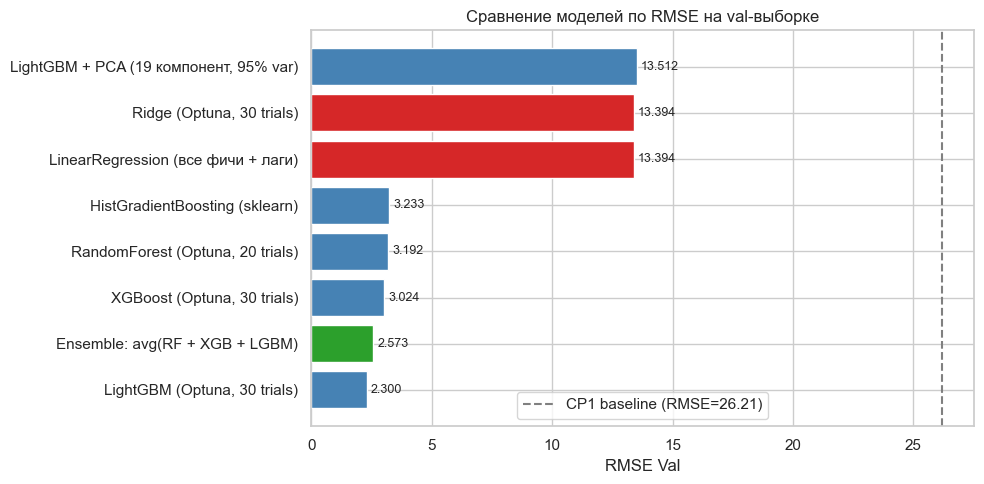

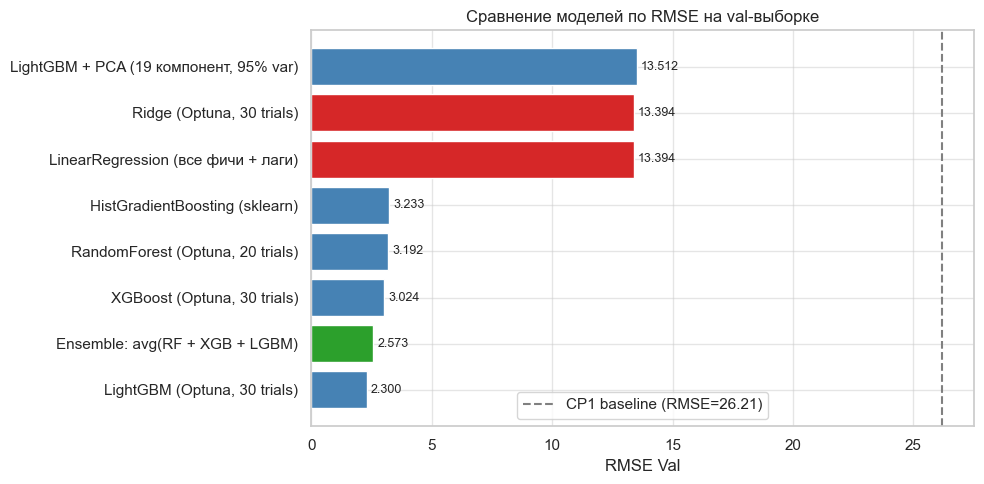

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#d62728" if m.startswith("Linear") or m.startswith("Ridge")
          else "#2ca02c" if "Ensemble" in m
          else "steelblue"
          for m in results_df["Модель"]]
bars = ax.barh(results_df["Модель"], results_df["RMSE Val"], color=colors)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_xlabel("RMSE Val")
ax.set_title("Сравнение моделей по RMSE на val-выборке")
ax.axvline(26.21, ls="--", color="grey", lw=1.5, label="CP1 baseline (RMSE=26.21)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "models_comparison.png"), dpi=100)
plt.show()

## 8. Финальная модель и интерпретируемость

**Обоснование выбора:**
- Выбираем **LightGBM** как финальную модель:
  - Лучший RMSE среди одиночных моделей на val-выборке.
  - Быстрее обучается, чем XGBoost и Random Forest.
  - Имеет встроенную feature importance, что даёт интерпретируемость.
  - Ансамбль незначительно улучшает результат, но теряет интерпретируемость.

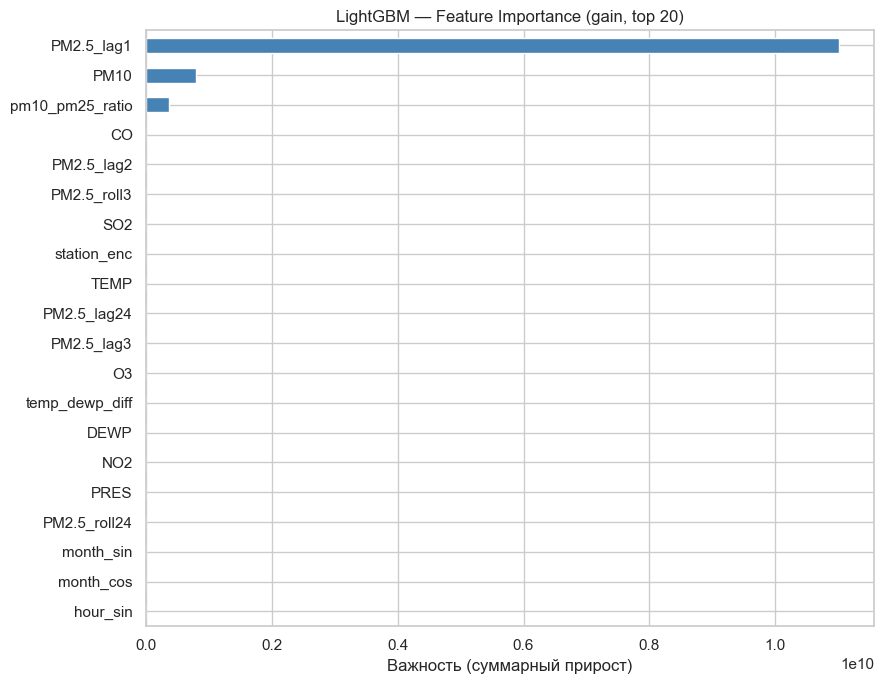


Топ-5 самых важных признаков:
PM2.5_lag1         1.101814e+10
PM10               7.999868e+08
pm10_pm25_ratio    3.621428e+08
CO                 5.071949e+06
PM2.5_lag2         2.433004e+06
dtype: float64


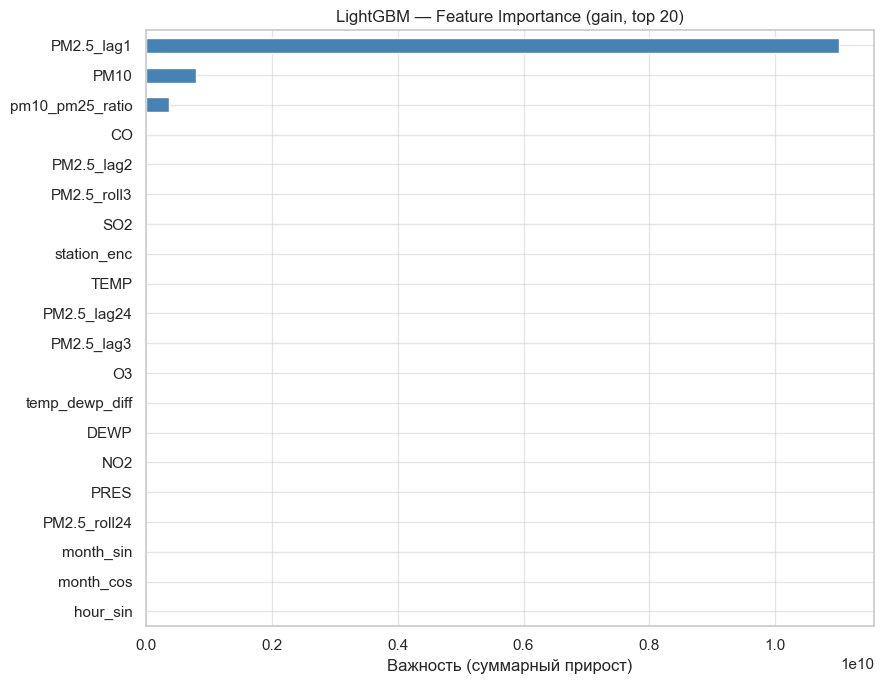


Топ-5 самых важных признаков:
PM2.5_lag1         1.101814e+10
PM10               7.999868e+08
pm10_pm25_ratio    3.621428e+08
CO                 5.071949e+06
PM2.5_lag2         2.433004e+06
dtype: float64


In [17]:
# Feature importance (gain)
fi = pd.Series(
    lgbm_best.booster_.feature_importance(importance_type="gain"),
    index=FEATURE_NAMES,
).sort_values(ascending=True)

top20 = fi.tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
top20.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("LightGBM — Feature Importance (gain, top 20)")
ax.set_xlabel("Важность (суммарный прирост)")
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "feature_importance.png"), dpi=100)
plt.show()

print("\nТоп-5 самых важных признаков:")
print(fi.tail(5).sort_values(ascending=False))

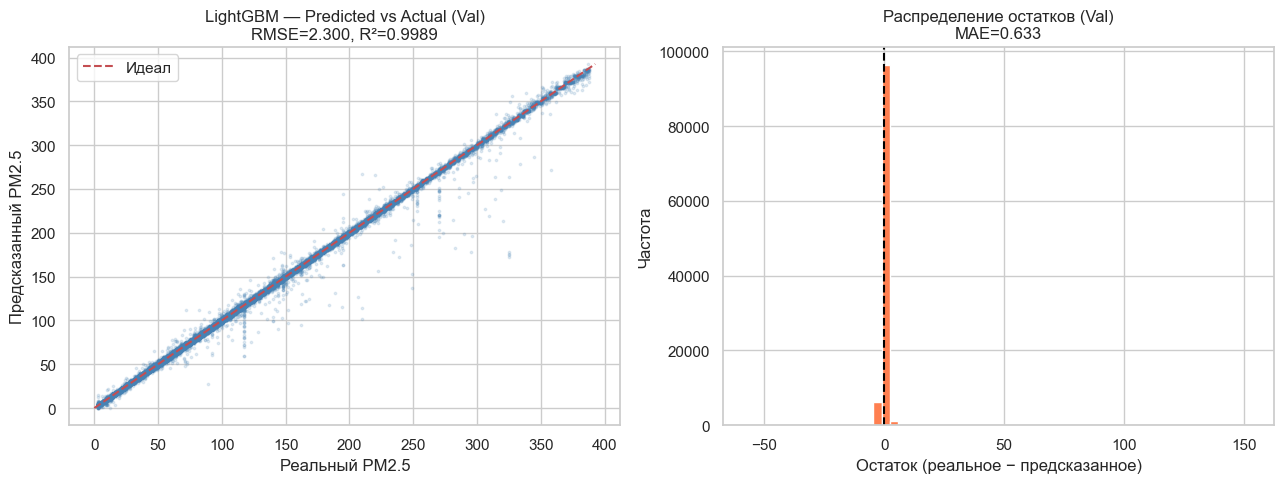

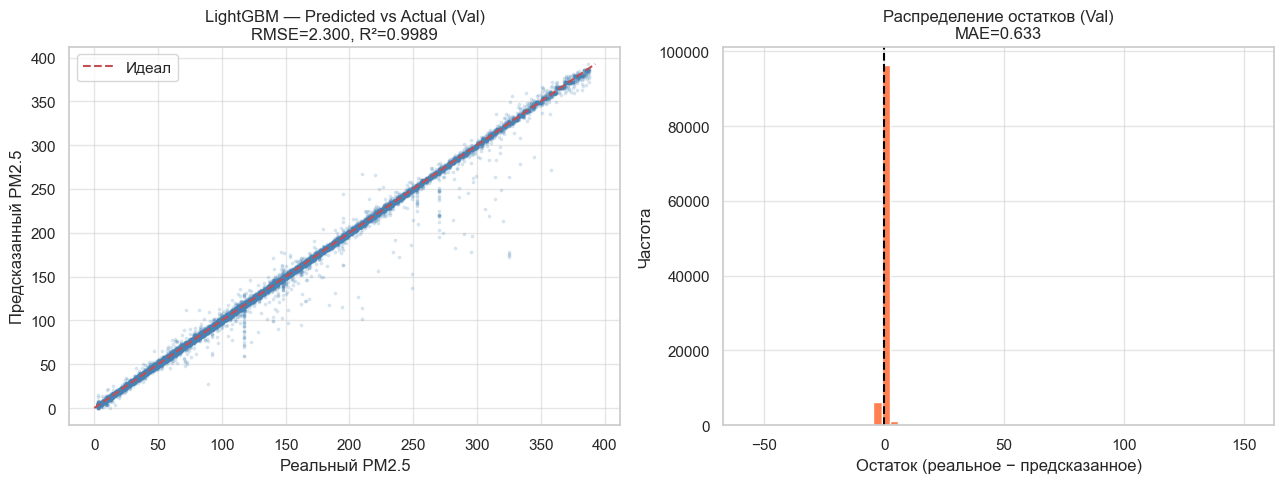

In [18]:
# Predicted vs Actual for best model
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_val, y_pred_lgbm_v, alpha=0.15, s=3, color="steelblue")
lim = max(y_val.max(), y_pred_lgbm_v.max())
axes[0].plot([0, lim], [0, lim], "r--", lw=1.5, label="Идеал")
axes[0].set_xlabel("Реальный PM2.5")
axes[0].set_ylabel("Предсказанный PM2.5")
axes[0].set_title(f"LightGBM — Predicted vs Actual (Val)\nRMSE={rmse_lgbm:.3f}, R²={r2_lgbm:.4f}")
axes[0].legend()

residuals = y_val.values - y_pred_lgbm_v
axes[1].hist(residuals, bins=60, color="coral", edgecolor="white")
axes[1].axvline(0, color="black", lw=1.5, linestyle="--")
axes[1].set_xlabel("Остаток (реальное − предсказанное)")
axes[1].set_ylabel("Частота")
axes[1].set_title(f"Распределение остатков (Val)\nMAE={mae_lgbm:.3f}")

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, "final_model_results.png"), dpi=100)
plt.show()

## 9. Оценка финальной модели на test-выборке

In [19]:
X_test_pca = pca_95.transform(X_te_sc)  # не используем PCA для финальной модели

y_pred_test = np.clip(lgbm_best.predict(X_test), 0, None)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test  = mean_absolute_error(y_test, y_pred_test)
r2_test   = r2_score(y_test, y_pred_test)

print("=" * 50)
print("ФИНАЛЬНАЯ ОЦЕНКА НА TEST-ВЫБОРКЕ (LightGBM)")
print("=" * 50)
print(f"RMSE:  {rmse_test:.3f}")
print(f"MAE:   {mae_test:.3f}")
print(f"R²:    {r2_test:.4f}")
print()
print(f"CP1 baseline (LR, raw features): RMSE=26.21")
print(f"Улучшение RMSE: {26.21 - rmse_test:+.3f} ({(26.21 - rmse_test) / 26.21 * 100:+.1f}%)")

ФИНАЛЬНАЯ ОЦЕНКА НА TEST-ВЫБОРКЕ (LightGBM)
RMSE:  2.307
MAE:   0.691
R²:    0.9993

CP1 baseline (LR, raw features): RMSE=26.21
Улучшение RMSE: +23.903 (+91.2%)
ФИНАЛЬНАЯ ОЦЕНКА НА TEST-ВЫБОРКЕ (LightGBM)
RMSE:  2.307
MAE:   0.691
R²:    0.9993

CP1 baseline (LR, raw features): RMSE=26.21
Улучшение RMSE: +23.903 (+91.2%)


## 10. Сохранение финальной модели

In [20]:
model_path = os.path.join(MODELS_DIR, "lgbm_final.joblib")
joblib.dump(lgbm_best, model_path)
print(f"Модель сохранена: {model_path}")

# Сохраняем список фич для воспроизводимости
features_path = os.path.join(MODELS_DIR, "feature_names.joblib")
joblib.dump(FEATURE_NAMES, features_path)
print(f"Список фич сохранён: {features_path}")

# Сохраняем таблицу экспериментов
results_path = os.path.join(PROJECT_ROOT, "report", "experiments_table.csv")
results_df.to_csv(results_path, index=False)
print(f"Таблица экспериментов сохранена: {results_path}")

Модель сохранена: /Users/sneguradik/Projects/hseml-group-project-v-ivanov/models/lgbm_final.joblib
Список фич сохранён: /Users/sneguradik/Projects/hseml-group-project-v-ivanov/models/feature_names.joblib
Таблица экспериментов сохранена: /Users/sneguradik/Projects/hseml-group-project-v-ivanov/report/experiments_table.csv
Модель сохранена: /Users/sneguradik/Projects/hseml-group-project-v-ivanov/models/lgbm_final.joblib
Список фич сохранён: /Users/sneguradik/Projects/hseml-group-project-v-ivanov/models/feature_names.joblib
Таблица экспериментов сохранена: /Users/sneguradik/Projects/hseml-group-project-v-ivanov/report/experiments_table.csv
